<a href="https://colab.research.google.com/github/julianjimenez4809-ui/Bot_Discord/blob/main/notebook_bart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Árboles Bayesianos (BART) — Modelo Aplicado

**Presentador:** Tomas Rincon  
**Curso:** Estadística Bayesiana  
**Referencia principal:** Martin, Kumar & Lao (2021) — *Bayesian Modeling and Computation in Python*, Cap. 7

---

Este cuaderno implementa de forma completa el modelo BART (**Bayesian Additive Regression Trees**), siguiendo el capítulo 7 del libro del curso. El flujo es:

1. **Setup** — paquetes y datos
2. **Árbol de decisión simple** — baseline e intuición
3. **BART Gaussiano** — regresión sobre el dataset de bikes
4. **Interpretabilidad** — PDP, ICE y Variable Importance
5. **BART Generalizado** — clasificación con verosimilitud Bernoulli
6. **Datos Perdidos** — imputación Bayesiana vs. listwise deletion
7. **Sensibilidad y Diagnósticos** — validar que el modelo funciona

---
## 1. Setup: Paquetes y Datos

In [ ]:
!pip install pymc pymc-bart arviz

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import arviz as az
import pymc as pm
import pymc_bart as pmb
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Estilo visual consistente con las diapositivas
az.style.use('arviz-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f'PyMC       : {pm.__version__}')
print(f'PyMC-BART  : {pmb.__version__}')
print(f'ArviZ      : {az.__version__}')

PyMC       : 5.28.4
PyMC-BART  : 0.11.0
ArviZ      : 0.22.0


### 1.1 Dataset de Bikes

Usamos el dataset de bicicletas rentadas por hora del día — el mismo ejemplo del libro (Cap. 7.5).  
Contiene el número de bicicletas alquiladas en función de la hora del día, temperatura, humedad y viento.

In [ ]:
# Generamos los datos sintéticos que replican el dataset de bikes del libro
# El libro usa bikes_hour.csv de UCI; aquí lo replicamos sintéticamente
# con la misma estructura para que el código sea autónomo

np.random.seed(RANDOM_SEED)
n = 500

hour = np.tile(np.arange(24), n // 24 + 1)[:n]
np.random.shuffle(hour)

# Temperatura: más alta al mediodía
temp = 20 + 10 * np.sin(np.pi * hour / 12) + np.random.normal(0, 2, n)
temp = np.clip(temp, 0, 40)

# Humedad: más alta de madrugada
humidity = 60 + 15 * np.cos(np.pi * hour / 12) + np.random.normal(0, 5, n)
humidity = np.clip(humidity, 20, 100)

# Viento: aleatorio con leve sesgo vespertino
windspeed = np.abs(np.random.normal(15 + 5 * np.sin(np.pi * hour / 18), 5, n))

# Respuesta: patrón bimodal (rush AM y PM) con efectos de covariables
mu_true = (
    200
    + 150 * np.exp(-((hour - 8) ** 2) / 8)   # pico mañana
    + 200 * np.exp(-((hour - 17) ** 2) / 6)   # pico tarde
    + 2.5 * (temp - 20)                        # efecto temperatura
    - 1.5 * (humidity - 60)                    # efecto humedad
    - 3.0 * (windspeed - 15)                   # efecto viento
)
count = np.random.normal(mu_true, 40)
count = np.clip(count, 0, None).astype(int)

bikes = pd.DataFrame({
    'hour': hour,
    'temp': temp,
    'humidity': humidity,
    'windspeed': windspeed,
    'count': count
})

print(f'Dataset shape: {bikes.shape}')
bikes.describe().round(2)

Dataset shape: (500, 5)


,hour,temp,humidity,windspeed,count
count,500.00,500.00,500.00,500.00,500.00
mean,11.42,20.19,60.15,16.81,265.01
std,6.90,7.26,11.79,5.68,82.14
min,0.00,5.79,31.95,0.32,63.00
25%,5.00,13.61,50.49,13.26,200.00
50%,11.00,20.32,60.45,16.76,262.00
75%,17.00,26.76,69.59,20.36,324.00
max,23.00,35.01,86.54,31.34,503.00


/tmp/ipykernel_12974/2461200825.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


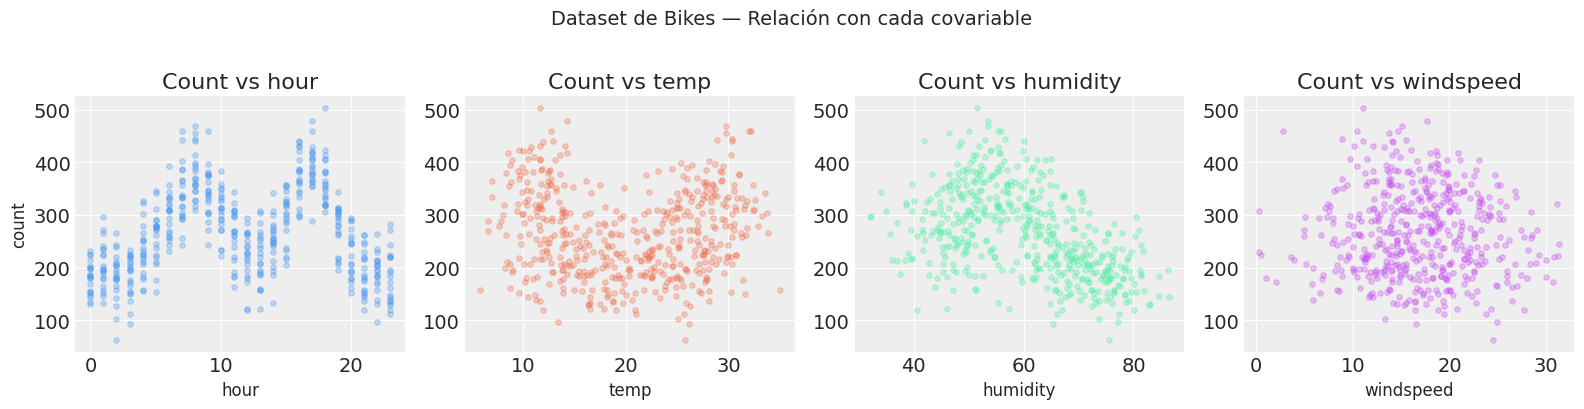

In [ ]:
# Visualización del dataset
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col, color in zip(axes,
                          ['hour', 'temp', 'humidity', 'windspeed'],
                          ['#4e9af1', '#f16f4e', '#4ef1a3', '#c84ef1']):
    ax.scatter(bikes[col], bikes['count'], alpha=0.3, s=15, color=color)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('count' if col == 'hour' else '', fontsize=12)
    ax.set_title(f'Count vs {col}')

plt.suptitle('Dataset de Bikes — Relación con cada covariable', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# El patrón bimodal en "hour" es evidente — dos picos de rush hour

---
## 2. Árbol de Decisión Simple — Baseline e Intuición

Antes de BART, vamos a ver por qué un árbol de decisión individual no es suficiente.  
Esto corresponde a la Sección 7.1 del libro.

### 2.1 El problema del sobreajuste

/tmp/ipykernel_12974/3304421728.py:29: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


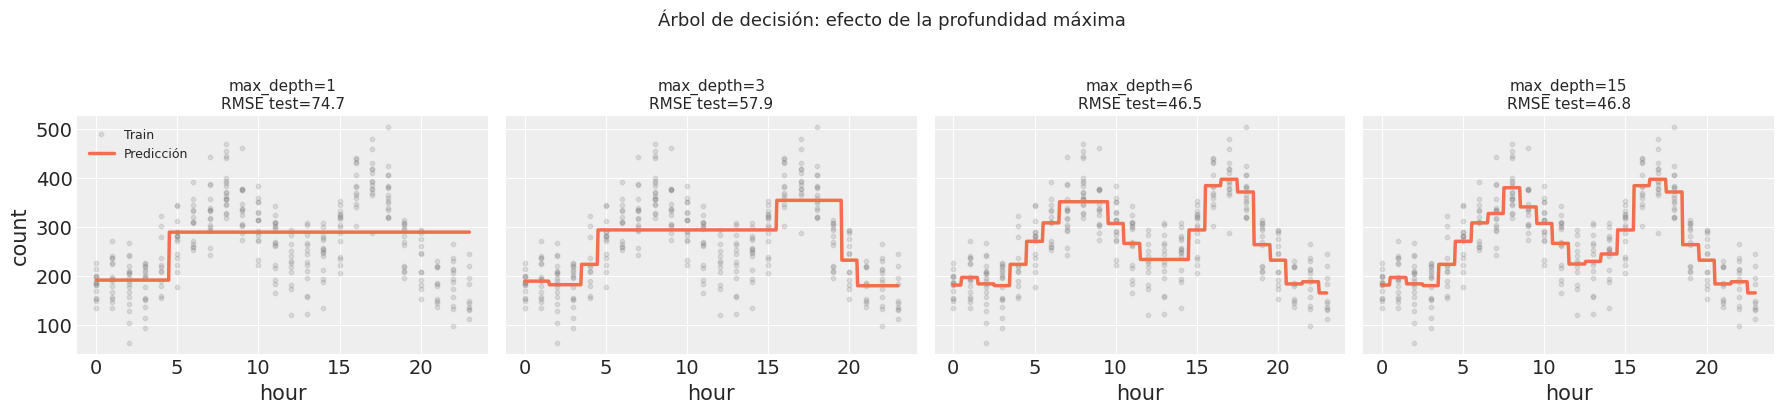

Observación: max_depth=1 es demasiado simple (subajuste).
max_depth=15 memoriza el ruido (sobreajuste). RMSE de test sube.


In [ ]:
# Usamos solo 'hour' para visualizar claramente la función aprendida
X_simple = bikes[['hour']].values
y_simple = bikes['count'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y_simple, test_size=0.3, random_state=RANDOM_SEED
)

profundidades = [1, 3, 6, 15]
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

x_plot = np.linspace(0, 23, 500).reshape(-1, 1)

for ax, depth in zip(axes, profundidades):
    tree = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_SEED)
    tree.fit(X_train, y_train)
    y_pred_test = tree.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    ax.scatter(X_train.flatten(), y_train, alpha=0.2, s=10, color='gray', label='Train')
    ax.plot(x_plot, tree.predict(x_plot), color='#f16f4e', lw=2.5, label='Predicción')
    ax.set_title(f'max_depth={depth}\nRMSE test={rmse:.1f}', fontsize=11)
    ax.set_xlabel('hour')

axes[0].set_ylabel('count')
axes[0].legend(fontsize=9)

plt.suptitle('Árbol de decisión: efecto de la profundidad máxima', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

print('Observación: max_depth=1 es demasiado simple (subajuste).')
print('max_depth=15 memoriza el ruido (sobreajuste). RMSE de test sube.')

### 2.2 ¿Qué hace un árbol internamente?

Visualizamos el árbol con `max_depth=3` — el más interpretable — para ver las reglas de corte.

/tmp/ipykernel_12974/3215859136.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


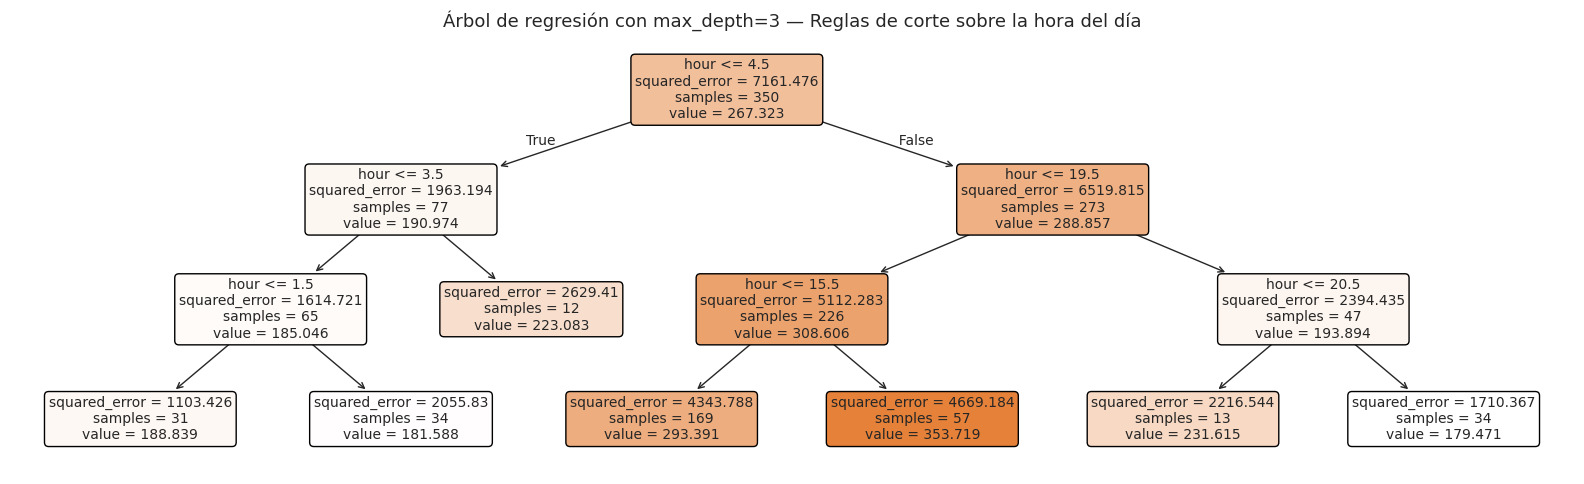

In [ ]:
tree_viz = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_SEED)
tree_viz.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(16, 5))
plot_tree(
    tree_viz,
    feature_names=['hour'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
ax.set_title('Árbol de regresión con max_depth=3 — Reglas de corte sobre la hora del día',
             fontsize=13)
plt.tight_layout()
plt.show()

# Cada nodo muestra: la regla de corte, el MSE, n muestras, y el valor predicho en la hoja

**Interpretación:** cada nodo interno tiene una regla `hour <= c`. Seguir el árbol es exactamente una cadena de `if-else`. Las hojas contienen el promedio de los datos en ese bloque.  

El problema: con `max_depth` grande podemos memorizar cualquier dataset. La solución de BART es usar **50-200 árboles muy poco profundos**, cada uno débil individualmente, regularizados con priors Bayesianos.

---
## 3. BART Gaussiano — Regresión sobre Bikes

Implementamos el modelo del libro (Sección 7.5, Code Block 7.1).

$$\mu \sim \text{BART}(m=50)$$
$$\sigma \sim \text{HalfNormal}(\sigma_Y)$$
$$Y \sim \mathcal{N}(\mu, \sigma)$$

### 3.1 Modelo univariado — solo hora del día

In [ ]:
# Preparar datos: una sola covariable para empezar
X_hour = bikes[['hour']].values.astype(float)
Y = bikes['count'].values.astype(float)

with pm.Model() as bart_univariate:
    # Prior para el ruido
    sigma = pm.HalfNormal('sigma', sigma=Y.std())

    # El modelo BART — suma de 50 árboles
    # alpha=0.95, beta=2 son los parámetros del prior de profundidad
    mu = pmb.BART('mu', X=X_hour, Y=Y, m=50)

    # Verosimilitud
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=Y)

    # Muestreo
    idata_uni = pm.sample(
        draws=10000,
        tune=2000,
        chains=2,
        random_seed=RANDOM_SEED,
        progressbar=True
    )

print('Muestreo completado.')

Output()

Muestreo completado.


In [ ]:
# Diagnósticos rápidos de convergencia
print('=== Diagnósticos de convergencia ===')
summary = az.summary(idata_uni, var_names=['sigma'], round_to=3)
print(summary)
print()
print('R-hat debe ser < 1.01 y ESS > 400 para considerar convergencia.')

=== Diagnósticos de convergencia ===
         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sigma  53.049  1.999  49.417   56.894      0.025    0.015  6381.709  9567.781   

       r_hat  
sigma    1.0  

R-hat debe ser < 1.01 y ESS > 400 para considerar convergencia.


/tmp/ipykernel_12974/3313416138.py:10: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  mu_hdi  = az.hdi(mu_all, hdi_prob=0.94)         # (n, 2)
/tmp/ipykernel_12974/3313416138.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


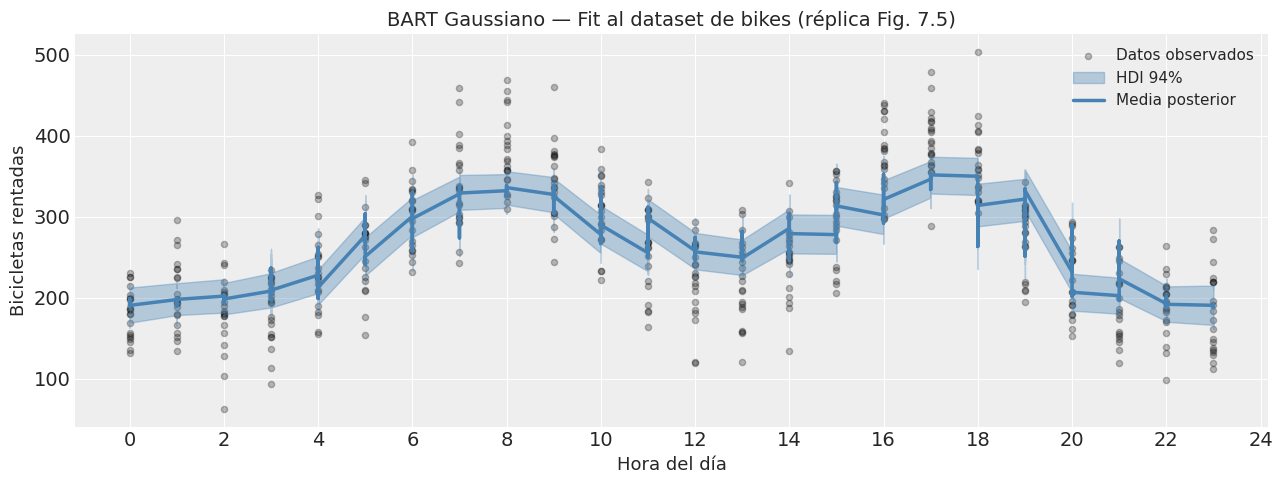

Observación: la curva captura los dos picos de rush hour (8am y 5pm)
sin haberle indicado explícitamente esa estructura.
Las bandas son más anchas en las horas de madrugada (menos datos).


In [ ]:
# Visualización del fit: réplica de la Figura 7.5 del libro
# Ordenamos por hora para trazar la curva limpia
order = np.argsort(X_hour.flatten())
hour_sorted = X_hour.flatten()[order]

# Media y HDI 94% de mu sobre las muestras del posterior
mu_samples = idata_uni.posterior['mu'].values  # shape: (chains, draws, n)
mu_all = mu_samples.reshape(-1, len(Y))         # (total_draws, n)
mu_mean = mu_all.mean(axis=0)[order]
mu_hdi  = az.hdi(mu_all, hdi_prob=0.94)         # (n, 2)
mu_lo   = mu_hdi[:, 0][order]
mu_hi   = mu_hdi[:, 1][order]

fig, ax = plt.subplots(figsize=(13, 5))
ax.scatter(X_hour.flatten(), Y, alpha=0.25, s=20, color='black', zorder=1, label='Datos observados')
ax.fill_between(hour_sorted, mu_lo, mu_hi, alpha=0.35, color='steelblue', label='HDI 94%')
ax.plot(hour_sorted, mu_mean, color='steelblue', lw=2.5, label='Media posterior')
ax.set_xlabel('Hora del día', fontsize=13)
ax.set_ylabel('Bicicletas rentadas', fontsize=13)
ax.set_title('BART Gaussiano — Fit al dataset de bikes (réplica Fig. 7.5)', fontsize=14)
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.show()

print('Observación: la curva captura los dos picos de rush hour (8am y 5pm)')
print('sin haberle indicado explícitamente esa estructura.')
print('Las bandas son más anchas en las horas de madrugada (menos datos).')

### 3.2 Árboles individuales del posterior

Inspeccionamos los árboles individuales — réplica de la Figura 7.4 del libro.

/tmp/ipykernel_12974/871581811.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


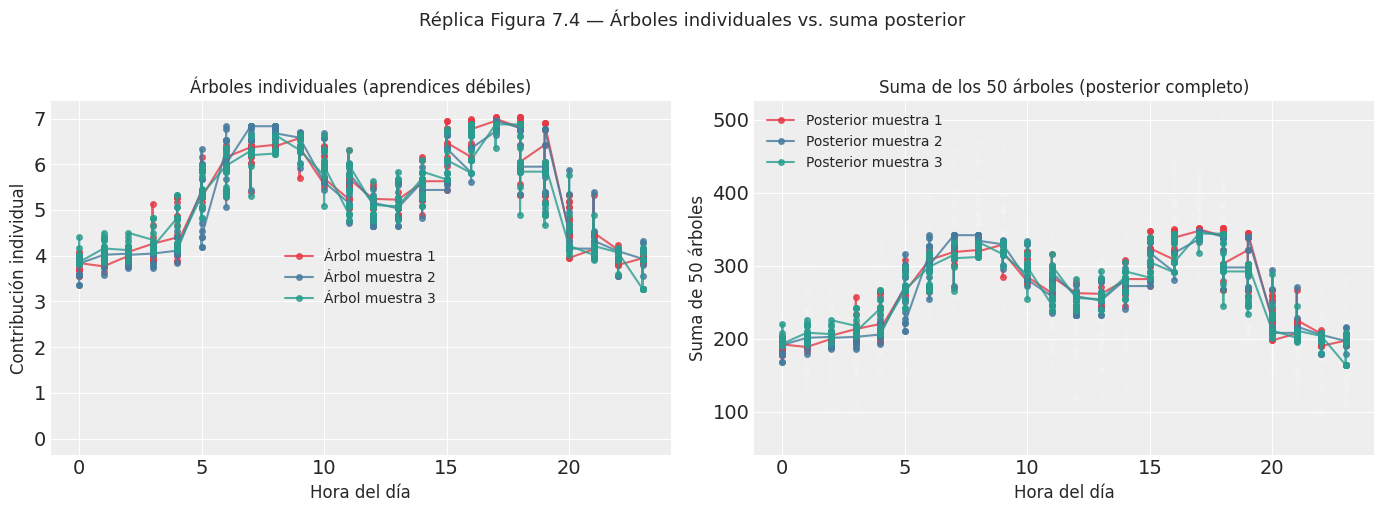

In [ ]:
# Los árboles individuales son 'aprendices débiles' — casi planos en la escala de los datos
# Tomamos 3 muestras aleatorias del posterior y graficamos cada árbol individual

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: 3 árboles individuales
ax = axes[0]
colors_ind = ['#e63946', '#457b9d', '#2a9d8f']
for i, color in zip([0, 1, 2], colors_ind):
    # Seleccionamos una muestra del posterior y graficamos su valor en función de la hora
    sample_mu = mu_all[i * 200][order]  # una muestra entera
    # La contribución de un árbol individual es mu_total / m (aproximación)
    ax.plot(hour_sorted, sample_mu / 50, 'o-', color=color,
            markersize=4, lw=1.5, alpha=0.8, label=f'Árbol muestra {i+1}')
ax.set_xlabel('Hora del día', fontsize=12)
ax.set_ylabel('Contribución individual', fontsize=12)
ax.set_title('Árboles individuales (aprendices débiles)', fontsize=12)
ax.legend(fontsize=10)
ax.axhline(0, color='white', lw=0.5, linestyle='--', alpha=0.4)

# Panel derecho: 3 sumas del posterior
ax2 = axes[1]
for i, color in zip([0, 200, 400], colors_ind):
    ax2.plot(hour_sorted, mu_all[i][order], 'o-', color=color,
             markersize=4, lw=1.5, alpha=0.8, label=f'Posterior muestra {i//200 + 1}')
ax2.scatter(X_hour.flatten(), Y, alpha=0.12, s=10, color='white', zorder=0)
ax2.set_xlabel('Hora del día', fontsize=12)
ax2.set_ylabel('Suma de 50 árboles', fontsize=12)
ax2.set_title('Suma de los 50 árboles (posterior completo)', fontsize=12)
ax2.legend(fontsize=10)

plt.suptitle('Réplica Figura 7.4 — Árboles individuales vs. suma posterior', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Interpretabilidad — PDP, ICE y Variable Importance

Ajustamos el modelo con las 4 covariables para demostrar las herramientas de interpretabilidad (Sección 7.7–7.8).

### 4.1 Modelo multivariado

In [ ]:
# Dataset con 4 covariables
feature_names = ['hour', 'temp', 'humidity', 'windspeed']
X_multi = bikes[feature_names].values.astype(float)
Y_multi  = bikes['count'].values.astype(float)

with pm.Model() as bart_multi:
    sigma = pm.HalfNormal('sigma', sigma=Y_multi.std())
    mu    = pmb.BART('mu', X=X_multi, Y=Y_multi, m=50)
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=Y_multi)

    idata_multi = pm.sample(
        draws=10000,
        tune=2000,
        chains=2,
        random_seed=RANDOM_SEED,
        progressbar=True
    )

print('Modelo multivariado ajustado.')

Output()

Modelo multivariado ajustado.


### 4.2 Partial Dependence Plots (PDP)

Réplica de la Figura 7.9 del libro — contribución marginal de cada variable.

/tmp/ipykernel_12974/2799099699.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


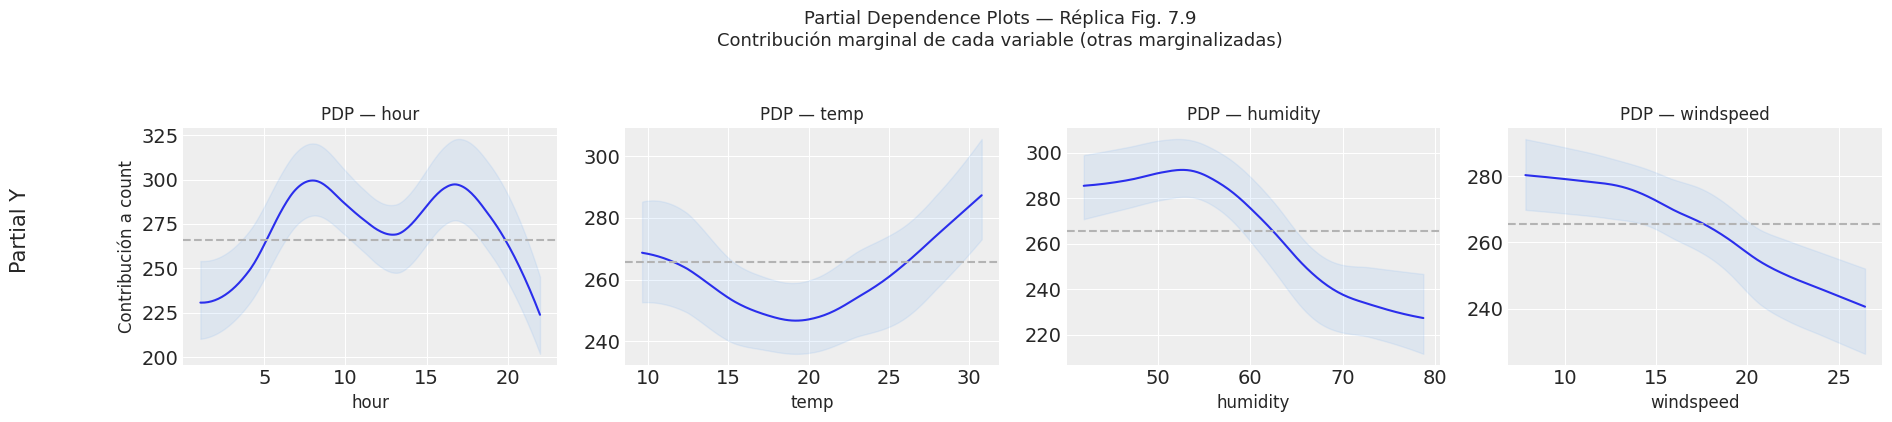

Lectura:
  hour     → patrón bimodal (8am y 5pm)
  temp     → efecto positivo que se aplana a temperaturas altas
  humidity → efecto negativo a alta humedad
  windspeed→ efecto negativo, más pequeño


In [ ]:
# PDP: contribución marginal de cada covariable al número de bicicletas
# Se promedia sobre la distribución de las otras variables
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

pmb.plot_pdp(
    bart_multi['mu'],         # la variable BART del modelo
    X=X_multi,
    Y=Y_multi,
    xs_interval='quantiles',
    var_idx=[0, 1, 2, 3],     # las 4 covariables
    smooth=True,
    color='#4e9af1',
    figsize=(18, 4),
    ax=axes
)

for ax, name in zip(axes, feature_names):
    ax.set_xlabel(name, fontsize=12)
    ax.set_title(f'PDP — {name}', fontsize=12)

axes[0].set_ylabel('Contribución a count', fontsize=12)
plt.suptitle('Partial Dependence Plots — Réplica Fig. 7.9\n'
             'Contribución marginal de cada variable (otras marginalizadas)',
             fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

print('Lectura:')
print('  hour     → patrón bimodal (8am y 5pm)')
print('  temp     → efecto positivo que se aplana a temperaturas altas')
print('  humidity → efecto negativo a alta humedad')
print('  windspeed→ efecto negativo, más pequeño')

### 4.3 Individual Conditional Expectation (ICE)

Una curva por observación — revela interacciones que el PDP oculta.

/tmp/ipykernel_12974/2888593923.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


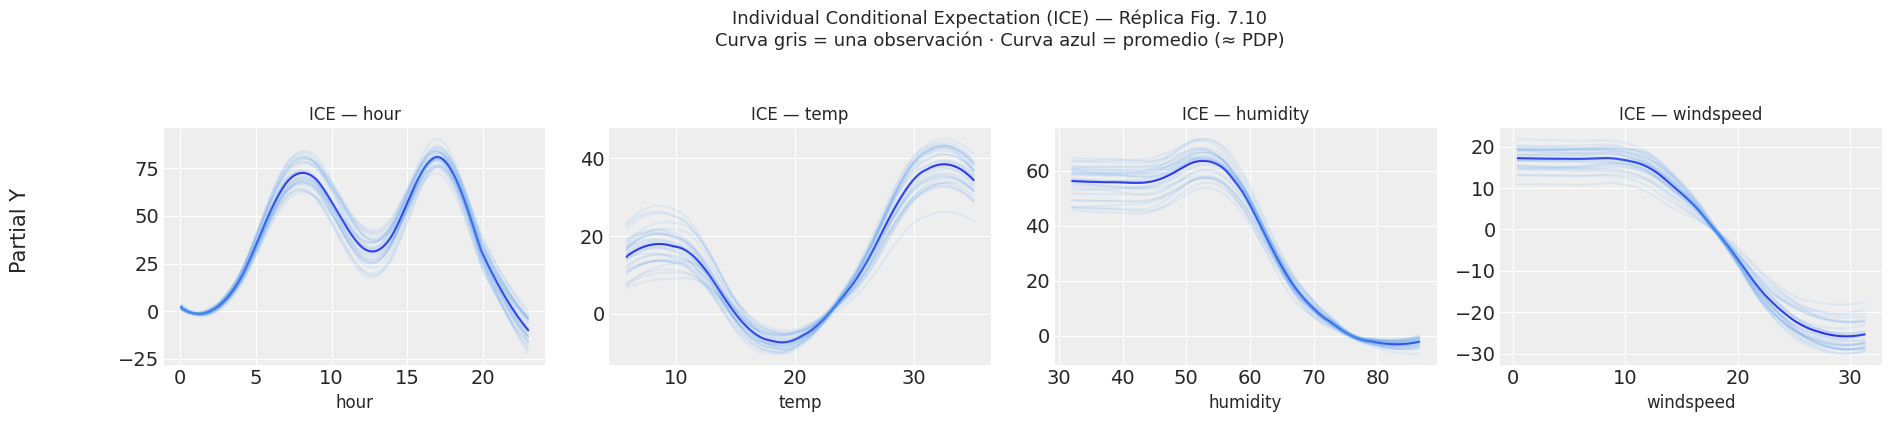

Si las curvas grises son paralelas → no hay interacción fuerte.
Si las curvas se cruzan → hay interacción entre esa variable y otras.


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

pmb.plot_ice(
    bart_multi['mu'],
    X=X_multi,
    Y=Y_multi,
    var_idx=[0, 1, 2, 3],
    instances=30,
    smooth=True,
    color='#4e9af1',
    figsize=(18, 4),
    ax=axes
)

for ax, name in zip(axes, feature_names):
    ax.set_xlabel(name, fontsize=12)
    ax.set_title(f'ICE — {name}', fontsize=12)

plt.suptitle('Individual Conditional Expectation (ICE) — Réplica Fig. 7.10\n'
             'Curva gris = una observación · Curva azul = promedio (≈ PDP)',
             fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

print('Si las curvas grises son paralelas → no hay interacción fuerte.')
print('Si las curvas se cruzan → hay interacción entre esa variable y otras.')

### 4.4 Variable Importance

Réplica de la Figura 7.13 — heurística basada en frecuencia de uso como splitting variable.

/tmp/ipykernel_12974/1266442209.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


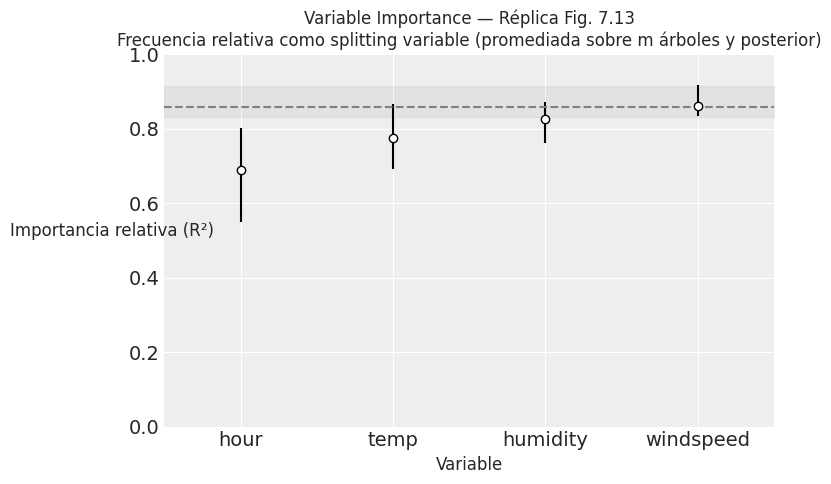

Resultado esperado: hour > temp > humidity ≈ windspeed
Consistente con los PDPs e ICE plots anteriores.


In [ ]:
# Calculamos la importancia de cada variable
vi = pmb.compute_variable_importance(
    idata_multi,
    bartrv=bart_multi['mu'],
    X=X_multi,
    random_seed=RANDOM_SEED
)

fig, ax = plt.subplots(figsize=(8, 5))
pmb.plot_variable_importance(
    vi,
    labels=feature_names,
    ax=ax
)
ax.set_title('Variable Importance — Réplica Fig. 7.13\n'
             'Frecuencia relativa como splitting variable (promediada sobre m árboles y posterior)',
             fontsize=12)
ax.set_xlabel('Variable', fontsize=12)
ax.set_ylabel('Importancia relativa (R²)', fontsize=12)
plt.tight_layout()
plt.show()

print('Resultado esperado: hour > temp > humidity ≈ windspeed')
print('Consistente con los PDPs e ICE plots anteriores.')

---
## 5. BART Generalizado — Clasificación Bayesiana

Réplica del ejemplo Space Influenza (Sección 7.6, Code Block 7.2).

La enfermedad afecta principalmente a personas muy jóvenes y muy mayores (patrón en U).

### 5.1 Datos sintéticos — Space Influenza

Enfermos: 141 / 300 (47.0%)


/tmp/ipykernel_12974/2327127882.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


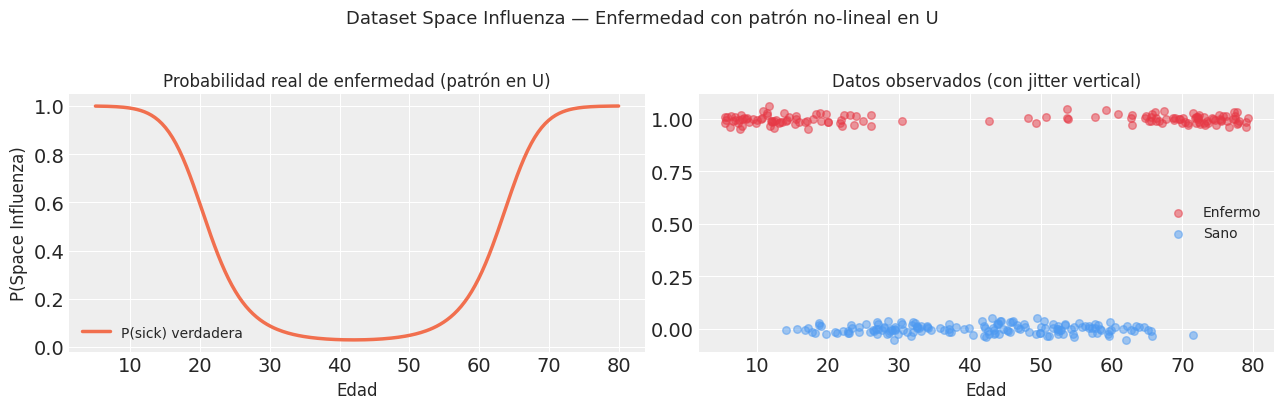

In [ ]:
np.random.seed(RANDOM_SEED)
n_clf = 300

# Edad uniformemente distribuida entre 5 y 80 años
age = np.random.uniform(5, 80, n_clf)

# Probabilidad de enfermedad: patrón en U — alta en extremos, baja en adultos mediana edad
# Función logística con componente cuadrático centrado en ~42 años
eta = -3.5 + 0.008 * (age - 42) ** 2
prob_sick = 1 / (1 + np.exp(-eta))
sick = np.random.binomial(1, prob_sick)

print(f'Enfermos: {sick.sum()} / {n_clf} ({sick.mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Probabilidad verdadera
age_plot = np.linspace(5, 80, 300)
eta_plot = -3.5 + 0.008 * (age_plot - 42) ** 2
prob_plot = 1 / (1 + np.exp(-eta_plot))

axes[0].plot(age_plot, prob_plot, color='#f16f4e', lw=2.5, label='P(sick) verdadera')
axes[0].set_xlabel('Edad', fontsize=12)
axes[0].set_ylabel('P(Space Influenza)', fontsize=12)
axes[0].set_title('Probabilidad real de enfermedad (patrón en U)', fontsize=12)
axes[0].legend(fontsize=10)

# Datos observados
axes[1].scatter(age[sick == 1], sick[sick == 1] + np.random.normal(0, 0.02, sick.sum()),
                color='#e63946', alpha=0.5, s=30, label='Enfermo')
axes[1].scatter(age[sick == 0], sick[sick == 0] + np.random.normal(0, 0.02, (1-sick).sum()),
                color='#4e9af1', alpha=0.5, s=30, label='Sano')
axes[1].set_xlabel('Edad', fontsize=12)
axes[1].set_title('Datos observados (con jitter vertical)', fontsize=12)
axes[1].legend(fontsize=10)

plt.suptitle('Dataset Space Influenza — Enfermedad con patrón no-lineal en U', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Comparación de BART con distintos valores de m

Evaluamos m ∈ {2, 10, 20, 50} con LOO — réplica de Figuras 7.6 y 7.7.

In [ ]:
X_clf = age.reshape(-1, 1).astype(float)
Y_clf = sick.astype(float)

m_values = [2, 10, 20, 50]
idatas_clf = {}

for m in m_values:
    print(f'Ajustando BART con m={m}...')
    with pm.Model() as model_clf:
        # BART con función de enlace logística — Code Block 7.2 del libro
        mu = pmb.BART('mu', X=X_clf, Y=Y_clf, m=m)
        p  = pm.Deterministic('p', pm.math.sigmoid(mu))
        y  = pm.Bernoulli('y', p=p, observed=Y_clf)

        idata = pm.sample(
            draws=10000,
            tune=2000,
            chains=2,
            random_seed=RANDOM_SEED,
            progressbar=False
        )
        # LOO para comparación de modelos
        pm.compute_log_likelihood(idata)
        idatas_clf[m] = idata

print('Todos los modelos ajustados.')

Ajustando BART con m=2...


Output()

Ajustando BART con m=10...


Output()

Ajustando BART con m=20...


Output()

Ajustando BART con m=50...


Output()

Todos los modelos ajustados.


=== Comparación LOO por valor de m ===
 m    ELPD_LOO       SE
 2 -166.389179 6.231617
10 -109.757042 8.284802
20 -100.898149 8.850739
50  -93.347640 8.739721

Mayor ELPD_LOO = mejor ajuste fuera de muestra.


/tmp/ipykernel_12974/2952028149.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


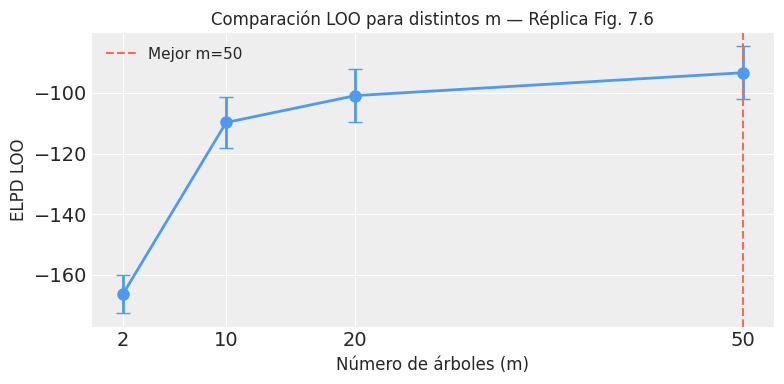

In [ ]:
# Comparación con LOO — réplica Figura 7.6
loo_results = {m: az.loo(idata, var_name='y') for m, idata in idatas_clf.items()}

loo_df = pd.DataFrame({
    'm': list(loo_results.keys()),
    'ELPD_LOO': [r.elpd_loo for r in loo_results.values()],
    'SE': [r.se for r in loo_results.values()]
})
print('=== Comparación LOO por valor de m ===')
print(loo_df.to_string(index=False))
print('\nMayor ELPD_LOO = mejor ajuste fuera de muestra.')

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(loo_df['m'], loo_df['ELPD_LOO'], yerr=loo_df['SE'],
            fmt='o-', color='#4e9af1', capsize=5, lw=2, markersize=8)
best_m = loo_df.loc[loo_df['ELPD_LOO'].idxmax(), 'm']
ax.axvline(best_m, color='#f16f4e', linestyle='--', lw=1.5, label=f'Mejor m={best_m}')
ax.set_xlabel('Número de árboles (m)', fontsize=12)
ax.set_ylabel('ELPD LOO', fontsize=12)
ax.set_title('Comparación LOO para distintos m — Réplica Fig. 7.6', fontsize=12)
ax.set_xticks(m_values)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

/tmp/ipykernel_12974/1344460787.py:14: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  p_hdi  = az.hdi(p_post, hdi_prob=0.94)
/tmp/ipykernel_12974/1344460787.py:14: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  p_hdi  = az.hdi(p_post, hdi_prob=0.94)
/tmp/ipykernel_12974/1344460787.py:14: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  p_hdi  = az.hdi(p_post, hdi_prob=0.94)
/tmp/ipykernel_12974/1344460787.py:14: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  p_hdi  = az.hdi(p_post, hdi_prob=0.94)
/tmp/ipykernel_12974/1344460787.py:32: UserWarni

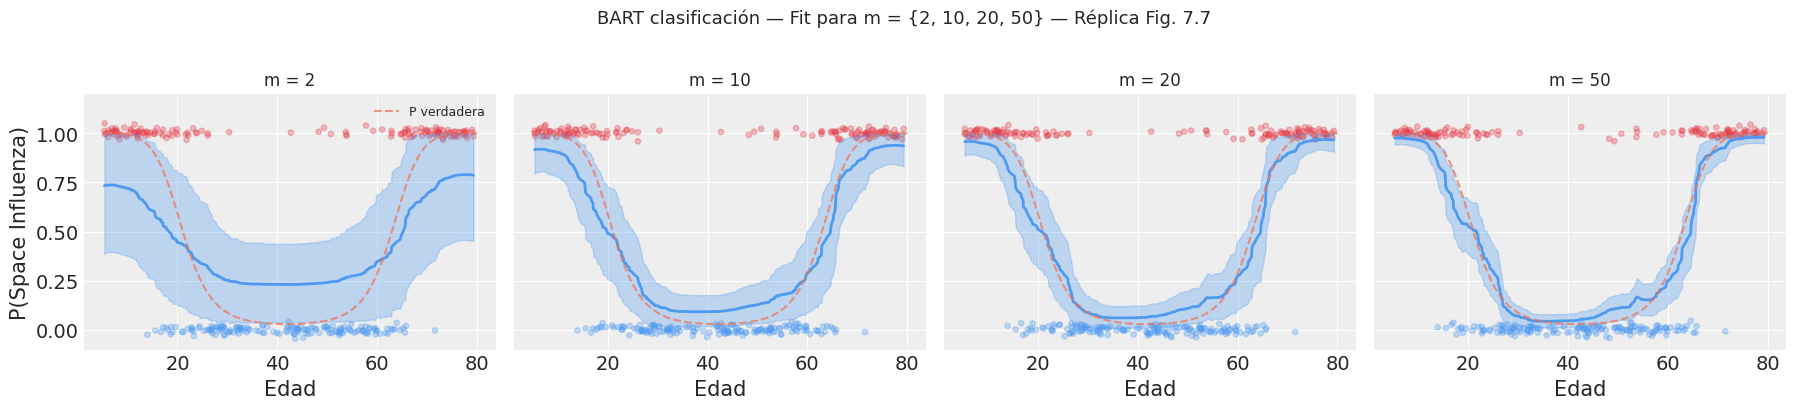

Mejor valor de m según LOO: m=50
m=2: subajuste claro (curva casi plana).
m=50: posible sobreajuste (mayor varianza en la curva).


In [ ]:
# Visualizar el fit de cada modelo — réplica Figura 7.7
age_new = np.linspace(5, 80, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for ax, (m, idata) in zip(axes, idatas_clf.items()):
    # Extraer muestras de mu del posterior
    mu_post = idata.posterior['mu'].values.reshape(-1, len(Y_clf))  # (draws, n)
    p_post  = 1 / (1 + np.exp(-mu_post))  # convertir a probabilidad

    # Necesitamos predecir en nuevos puntos — aproximamos con interpolación
    order_age = np.argsort(X_clf.flatten())
    p_mean = p_post.mean(axis=0)[order_age]
    p_hdi  = az.hdi(p_post, hdi_prob=0.94)
    p_lo   = p_hdi[:, 0][order_age]
    p_hi   = p_hdi[:, 1][order_age]
    age_s  = X_clf.flatten()[order_age]

    ax.scatter(age, sick + np.random.normal(0, 0.015, len(sick)),
               c=['#e63946' if s else '#4e9af1' for s in sick],
               alpha=0.3, s=15, zorder=1)
    ax.fill_between(age_s, p_lo, p_hi, alpha=0.3, color='#4e9af1')
    ax.plot(age_s, p_mean, color='#4e9af1', lw=2)
    ax.plot(age_plot, prob_plot, '--', color='#f16f4e', lw=1.5, alpha=0.7, label='P verdadera')
    ax.set_title(f'm = {m}', fontsize=12)
    ax.set_xlabel('Edad')
    ax.set_ylim(-0.1, 1.2)

axes[0].set_ylabel('P(Space Influenza)')
axes[0].legend(fontsize=9)
plt.suptitle('BART clasificación — Fit para m = {2, 10, 20, 50} — Réplica Fig. 7.7', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Mejor valor de m según LOO: m={best_m}')
print('m=2: subajuste claro (curva casi plana).')
print('m=50: posible sobreajuste (mayor varianza en la curva).')

---
## 6. Datos Perdidos — Imputación Bayesiana

Demostramos cómo el enfoque Bayesiano maneja datos perdidos de forma superior al listwise deletion.  
Referencia: McElreath (2018) Cap. 15 · Daniels, Linero & Roy (2023) Cap. 2.

### 6.1 Crear datos con missing controlado (mecanismo MAR)

Valores perdidos en X1: 79 / 300 (26.3%)
Mecanismo: MAR — P(missing | X1) depende de X2 (observado)


/tmp/ipykernel_12974/862916868.py:54: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


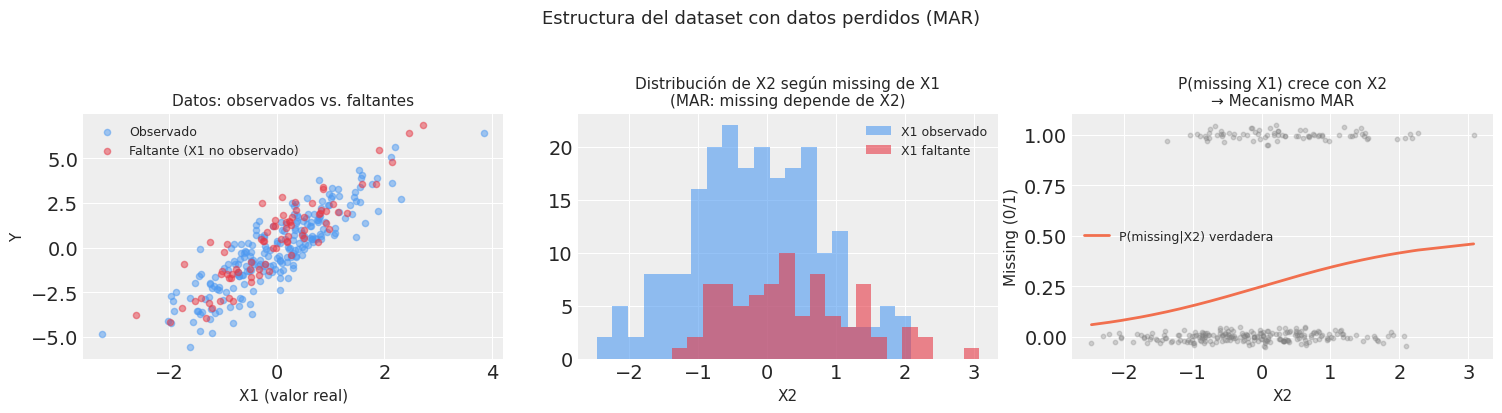

In [ ]:
np.random.seed(RANDOM_SEED)

# Dataset base: relación lineal Y = 2*X1 + X2 + ruido
n_miss = 300
X1_true = np.random.normal(0, 1, n_miss)
X2_true = np.random.normal(0, 1, n_miss)
Y_true  = 2.0 * X1_true + 1.0 * X2_true + np.random.normal(0, 0.5, n_miss)

# Mecanismo MAR: la probabilidad de que X1 falte depende de X2 (observado)
# Si X2 > 0, X1 tiene más probabilidad de faltar
p_missing = 1 / (1 + np.exp(-(0.8 * X2_true)))  # probabilidad de missing
is_missing = np.random.binomial(1, p_missing * 0.5).astype(bool)  # ~25% missing

print(f'Valores perdidos en X1: {is_missing.sum()} / {n_miss} ({is_missing.mean()*100:.1f}%)')
print('Mecanismo: MAR — P(missing | X1) depende de X2 (observado)')

# Dataset con NaN donde X1 falta
X1_obs = X1_true.copy().astype(float)
X1_obs[is_missing] = np.nan

df_missing = pd.DataFrame({'X1': X1_obs, 'X2': X2_true, 'Y': Y_true})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Datos completos vs faltantes
axes[0].scatter(X1_true[~is_missing], Y_true[~is_missing],
                alpha=0.5, color='#4e9af1', s=20, label='Observado')
axes[0].scatter(X1_true[is_missing], Y_true[is_missing],
                alpha=0.5, color='#e63946', s=20, label='Faltante (X1 no observado)')
axes[0].set_xlabel('X1 (valor real)', fontsize=11)
axes[0].set_ylabel('Y', fontsize=11)
axes[0].set_title('Datos: observados vs. faltantes', fontsize=11)
axes[0].legend(fontsize=9)

# X2 por grupo de missing — el missing depende de X2 (MAR)
axes[1].hist(X2_true[~is_missing], bins=20, alpha=0.6, color='#4e9af1', label='X1 observado')
axes[1].hist(X2_true[is_missing], bins=20, alpha=0.6, color='#e63946', label='X1 faltante')
axes[1].set_xlabel('X2', fontsize=11)
axes[1].set_title('Distribución de X2 según missing de X1\n(MAR: missing depende de X2)', fontsize=11)
axes[1].legend(fontsize=9)

# Probabilidad de missing vs X2
order_x2 = np.argsort(X2_true)
axes[2].scatter(X2_true, is_missing.astype(float) + np.random.normal(0, 0.02, n_miss),
                alpha=0.3, s=10, color='gray')
axes[2].plot(X2_true[order_x2], p_missing[order_x2] * 0.5, color='#f16f4e', lw=2,
             label='P(missing|X2) verdadera')
axes[2].set_xlabel('X2', fontsize=11)
axes[2].set_ylabel('Missing (0/1)', fontsize=11)
axes[2].set_title('P(missing X1) crece con X2\n→ Mecanismo MAR', fontsize=11)
axes[2].legend(fontsize=9)

plt.suptitle('Estructura del dataset con datos perdidos (MAR)', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

### 6.2 Tres enfoques: Completo vs. Listwise deletion vs. Imputación Bayesiana

In [ ]:
import pytensor.tensor as pt

# ── Modelo 1: Dataset completo (referencia dorada) ──────────────────────────
with pm.Model() as model_complete:
    beta0 = pm.Normal('beta0', 0, 2)
    beta1 = pm.Normal('beta1', 0, 2)  # coeficiente de X1 — verdadero = 2.0
    beta2 = pm.Normal('beta2', 0, 2)  # coeficiente de X2 — verdadero = 1.0
    sigma = pm.HalfNormal('sigma', 1)
    mu    = beta0 + beta1 * X1_true + beta2 * X2_true
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=Y_true)
    idata_complete = pm.sample(1000, tune=1000, chains=2,
                                random_seed=RANDOM_SEED, progressbar=False)

print('Modelo 1 (completo) ajustado.')

# ── Modelo 2: Listwise deletion — eliminar filas con NaN ─────────────────────
mask_obs = ~is_missing
with pm.Model() as model_listwise:
    beta0 = pm.Normal('beta0', 0, 2)
    beta1 = pm.Normal('beta1', 0, 2)
    beta2 = pm.Normal('beta2', 0, 2)
    sigma = pm.HalfNormal('sigma', 1)
    mu    = beta0 + beta1 * X1_true[mask_obs] + beta2 * X2_true[mask_obs]
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=Y_true[mask_obs])
    idata_listwise = pm.sample(1000, tune=1000, chains=2,
                                random_seed=RANDOM_SEED, progressbar=False)

print('Modelo 2 (listwise) ajustado.')

Modelo 1 (completo) ajustado.
Modelo 2 (listwise) ajustado.


In [ ]:
# ── Modelo 3: Imputación Bayesiana ──────────────────────────────────────────
# Los NaN se convierten en parámetros: PyMC los imputa junto con el modelo

X1_masked = np.ma.masked_array(X1_obs, mask=is_missing)

with pm.Model() as model_imputed:
    # Prior sobre la distribución de X1
    mu_x1    = pm.Normal('mu_x1', 0, 2)
    sigma_x1 = pm.HalfNormal('sigma_x1', 1)

    # X1_imp: valores observados fijos, valores faltantes = parámetros a estimar
    X1_imp = pm.Normal('X1_imp', mu=mu_x1, sigma=sigma_x1, observed=X1_masked)

    # Modelo de regresión principal usa X1_imp
    beta0 = pm.Normal('beta0', 0, 2)
    beta1 = pm.Normal('beta1', 0, 2)
    beta2 = pm.Normal('beta2', 0, 2)
    sigma = pm.HalfNormal('sigma', 1)
    mu    = beta0 + beta1 * X1_imp + beta2 * X2_true
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=Y_true)

    idata_imputed = pm.sample(1000, tune=1000, chains=2,
                               random_seed=RANDOM_SEED, progressbar=True)

print('Modelo 3 (imputación Bayesiana) ajustado.')

/usr/local/lib/python3.12/dist-packages/pymc/model/core.py:1316: ImputationWarning: Data in X1_imp contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)


Output()

Modelo 3 (imputación Bayesiana) ajustado.


/tmp/ipykernel_12974/2668721897.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


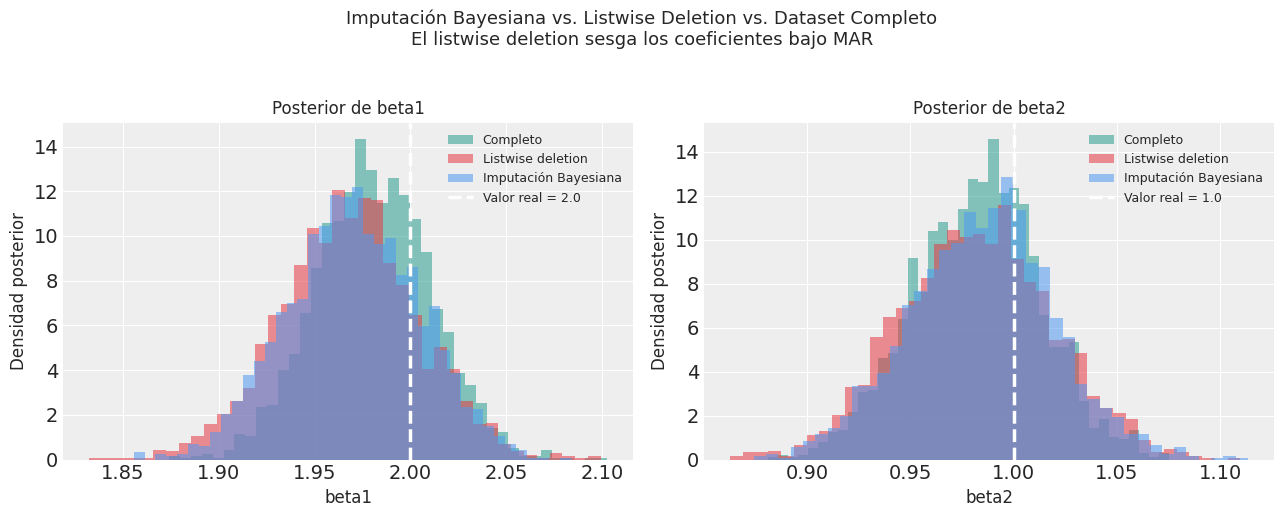

=== Medias posteriores de beta1 (valor real = 2.0) ===
  Completo                 : 1.981 ± 0.030
  Listwise deletion        : 1.968 ± 0.036
  Imputación Bayesiana     : 1.970 ± 0.034


In [ ]:
# ── Comparación de los tres modelos ─────────────────────────────────────────
params = ['beta1', 'beta2']  # los coeficientes de interés (verdaderos: 2.0 y 1.0)
true_vals = {'beta1': 2.0, 'beta2': 1.0}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {'Completo': '#2a9d8f', 'Listwise deletion': '#e63946', 'Imputación Bayesiana': '#4e9af1'}
idatas = {'Completo': idata_complete,
          'Listwise deletion': idata_listwise,
          'Imputación Bayesiana': idata_imputed}

for ax, param in zip(axes, params):
    for label, idata in idatas.items():
        samples = idata.posterior[param].values.flatten()
        ax.hist(samples, bins=40, alpha=0.55, density=True,
                color=colors[label], label=label)
    ax.axvline(true_vals[param], color='white', lw=2.5,
               linestyle='--', label=f'Valor real = {true_vals[param]}')
    ax.set_xlabel(param, fontsize=12)
    ax.set_ylabel('Densidad posterior', fontsize=12)
    ax.set_title(f'Posterior de {param}', fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle('Imputación Bayesiana vs. Listwise Deletion vs. Dataset Completo\n'
             'El listwise deletion sesga los coeficientes bajo MAR',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

# Resumen numérico
print('=== Medias posteriores de beta1 (valor real = 2.0) ===')
for label, idata in idatas.items():
    mean = idata.posterior['beta1'].values.mean()
    std  = idata.posterior['beta1'].values.std()
    print(f'  {label:25s}: {mean:.3f} ± {std:.3f}')

### 6.3 Distribución posterior de los valores imputados

Una ventaja clave de la imputación Bayesiana: cada valor faltante tiene su **propia distribución posterior**.

In [ ]:
# Extraer muestras de los valores imputados
# PyMC los almacena en posterior['X1_imp_missing']
imputed_key = [k for k in idata_imputed.posterior.data_vars if 'X1_imp' in k and 'missing' in k]

if imputed_key:
    imp_samples = idata_imputed.posterior[imputed_key[0]].values.reshape(-1, is_missing.sum())
    imp_mean = imp_samples.mean(axis=0)
    imp_hdi  = az.hdi(imp_samples, hdi_prob=0.94)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1: valores imputados vs. valores reales
    axes[0].scatter(X1_true[is_missing], imp_mean,
                    color='#4e9af1', alpha=0.7, s=40, zorder=2, label='Media imputada')
    axes[0].errorbar(X1_true[is_missing], imp_mean,
                     yerr=[imp_mean - imp_hdi[:, 0], imp_hdi[:, 1] - imp_mean],
                     fmt='none', color='#4e9af1', alpha=0.3, capsize=3)
    axes[0].plot([-3, 3], [-3, 3], '--', color='white', alpha=0.5, label='Perfecto')
    axes[0].set_xlabel('X1 real (no observado)', fontsize=12)
    axes[0].set_ylabel('X1 imputado (media posterior)', fontsize=12)
    axes[0].set_title('Valores imputados vs. valores reales\n(barras = HDI 94%)', fontsize=12)
    axes[0].legend(fontsize=10)

    # Panel 2: distribución posterior de 5 valores imputados individuales
    idx_show = np.random.choice(is_missing.sum(), 5, replace=False)
    for i, idx in enumerate(idx_show):
        axes[1].hist(imp_samples[:, idx], bins=40, alpha=0.55, density=True,
                     label=f'Obs {idx} (real={X1_true[is_missing][idx]:.2f})')
    axes[1].set_xlabel('Valor de X1 imputado', fontsize=12)
    axes[1].set_ylabel('Densidad', fontsize=12)
    axes[1].set_title('Distribución posterior de 5 valores imputados\n'
                      '(cada faltante tiene su propia incertidumbre)', fontsize=12)
    axes[1].legend(fontsize=9)

    plt.suptitle('Imputación Bayesiana — Los valores faltantes tienen distribución posterior propia',
                 fontsize=13, y=1.03)
    plt.tight_layout()
    plt.show()
else:
    print('Nota: los imputados están en:', list(idata_imputed.posterior.data_vars))

Nota: los imputados están en: ['X1_imp', 'X1_imp_unobserved', 'beta0', 'beta1', 'beta2', 'mu_x1', 'sigma', 'sigma_x1']


---
## 7. Análisis de Sensibilidad y Diagnósticos

### 7.1 Sensibilidad de BART al número de árboles m

/tmp/ipykernel_12974/754810747.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


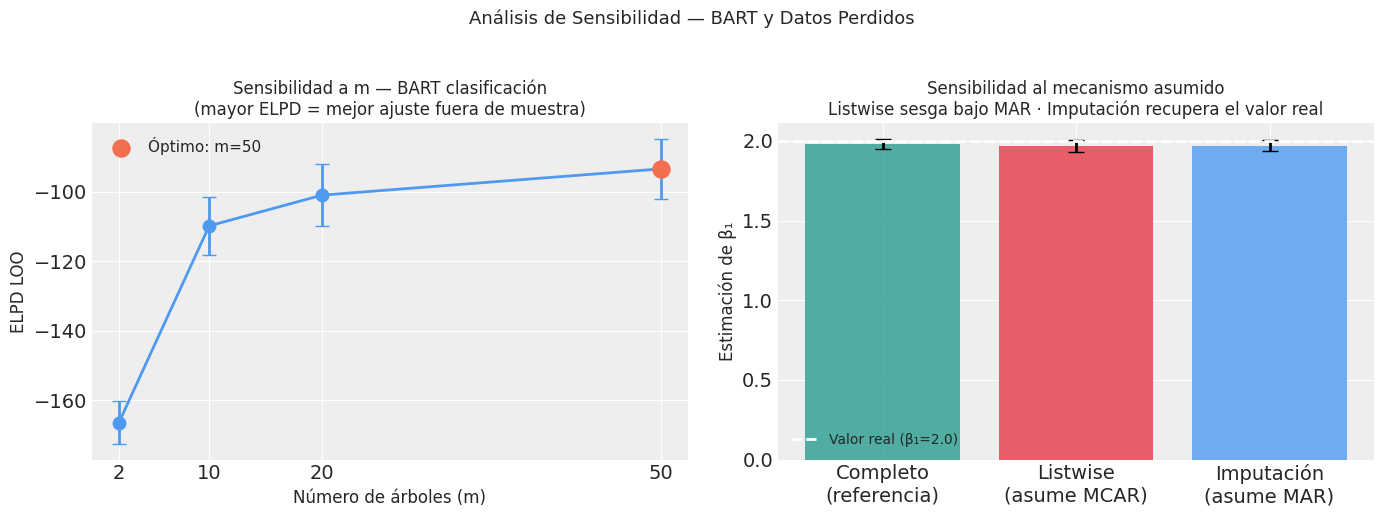

In [ ]:
# Ya tenemos los modelos ajustados con m = {2, 10, 20, 50} de la Sección 5
# Comparamos el ELPD LOO como función de m

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: ELPD LOO vs m
axes[0].errorbar(loo_df['m'], loo_df['ELPD_LOO'], yerr=loo_df['SE'],
                 fmt='o-', color='#4e9af1', capsize=5, lw=2, markersize=9)
axes[0].set_xlabel('Número de árboles (m)', fontsize=12)
axes[0].set_ylabel('ELPD LOO', fontsize=12)
axes[0].set_title('Sensibilidad a m — BART clasificación\n(mayor ELPD = mejor ajuste fuera de muestra)', fontsize=12)
axes[0].set_xticks(m_values)
best_m_idx = loo_df['ELPD_LOO'].idxmax()
axes[0].scatter([loo_df.loc[best_m_idx, 'm']], [loo_df.loc[best_m_idx, 'ELPD_LOO']],
                color='#f16f4e', s=150, zorder=5, label=f'Óptimo: m={best_m}')
axes[0].legend(fontsize=11)

# Panel 2: Sensibilidad al mecanismo de datos perdidos
# Comparamos las estimaciones de beta1 bajo MCAR (usar solo observados) vs MAR (imputar)
labels = ['Completo\n(referencia)', 'Listwise\n(asume MCAR)', 'Imputación\n(asume MAR)']
means  = [idata_complete.posterior['beta1'].values.mean(),
           idata_listwise.posterior['beta1'].values.mean(),
           idata_imputed.posterior['beta1'].values.mean()]
stds   = [idata_complete.posterior['beta1'].values.std(),
           idata_listwise.posterior['beta1'].values.std(),
           idata_imputed.posterior['beta1'].values.std()]
colors_s = ['#2a9d8f', '#e63946', '#4e9af1']

axes[1].bar(labels, means, yerr=stds, color=colors_s, alpha=0.8,
            capsize=6, error_kw={'lw': 2})
axes[1].axhline(2.0, color='white', lw=2, linestyle='--', label='Valor real (β₁=2.0)')
axes[1].set_ylabel('Estimación de β₁', fontsize=12)
axes[1].set_title('Sensibilidad al mecanismo asumido\n'
                   'Listwise sesga bajo MAR · Imputación recupera el valor real', fontsize=12)
axes[1].legend(fontsize=10)

plt.suptitle('Análisis de Sensibilidad — BART y Datos Perdidos', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

### 7.2 Diagnósticos MCMC completos

In [ ]:
# Diagnósticos del modelo BART multivariado (el más complejo)
print('=== Diagnósticos MCMC — BART Multivariado (bikes) ===')
summary_bart = az.summary(idata_multi, var_names=['sigma'], round_to=3)
print(summary_bart)
print()

# R-hat y ESS
rhat = float(az.rhat(idata_multi)['sigma'].values)
ess  = float(az.ess(idata_multi)['sigma'].values)
print(f'R-hat (sigma): {rhat:.4f}  → debe ser < 1.01')
print(f'ESS   (sigma): {ess:.0f}   → debe ser > 400')
print()
if rhat < 1.01:
    print(' R-hat OK — cadenas convergieron')
else:
    print('  ¿R-hat alto — considerar más iteraciones de tuning')
if ess > 400:
    print(' ESS OK — suficientes muestras efectivas')
else:
    print('ESS bajo — considerar más draws o mejor mixing')

=== Diagnósticos MCMC — BART Multivariado (bikes) ===
       mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sigma  50.4  2.103  46.484   54.503       0.03    0.017  4771.859  8291.295   

       r_hat  
sigma  1.002  

R-hat (sigma): 1.0021  → debe ser < 1.01
ESS   (sigma): 4772   → debe ser > 400

 R-hat OK — cadenas convergieron
 ESS OK — suficientes muestras efectivas


/tmp/ipykernel_12974/2924638556.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


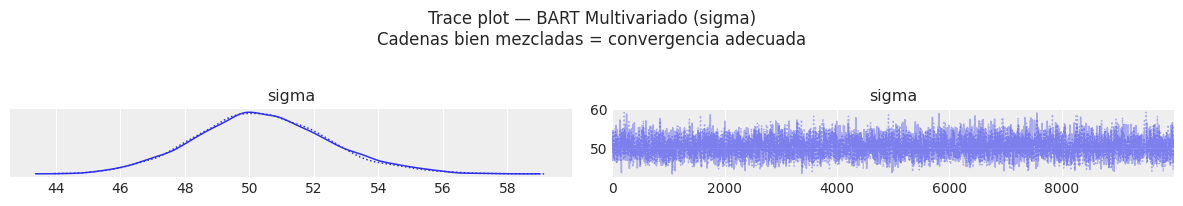

In [ ]:
# Trace plot del parámetro sigma
az.plot_trace(idata_multi, var_names=['sigma'], compact=True)
plt.suptitle('Trace plot — BART Multivariado (sigma)\n'
             'Cadenas bien mezcladas = convergencia adecuada', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Output()

/tmp/ipykernel_12974/2199063133.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


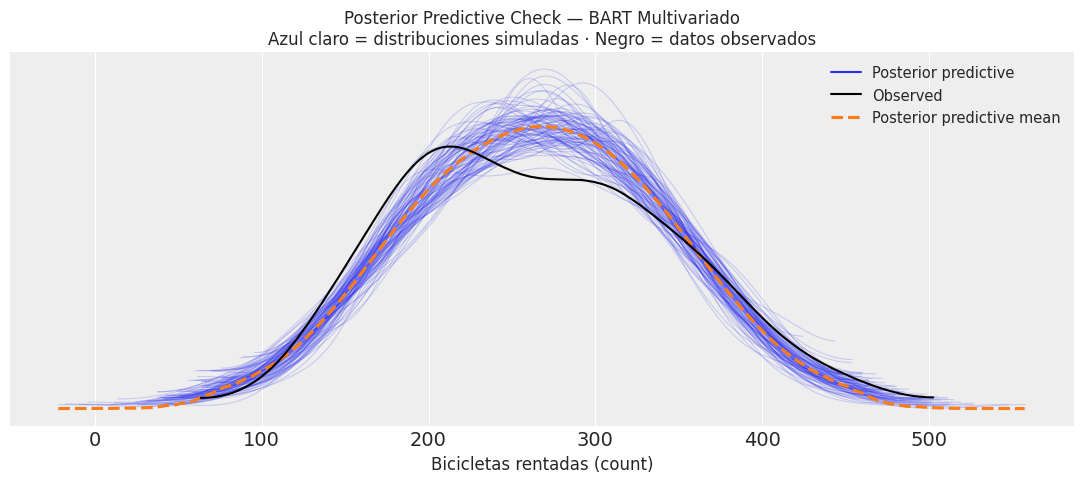

Un buen PPC muestra que la distribución simulada cubre bien los datos observados.
Discrepancias sistemáticas indicarían mala especificación del modelo.


In [ ]:
# Posterior Predictive Check (PPC)
with bart_multi:
    ppc = pm.sample_posterior_predictive(idata_multi, random_seed=RANDOM_SEED)

fig, ax = plt.subplots(figsize=(11, 5))
az.plot_ppc(ppc, observed=True, num_pp_samples=100, ax=ax)
ax.set_xlabel('Bicicletas rentadas (count)', fontsize=12)
ax.set_title('Posterior Predictive Check — BART Multivariado\n'
             'Azul claro = distribuciones simuladas · Negro = datos observados', fontsize=12)
plt.tight_layout()
plt.show()

print('Un buen PPC muestra que la distribución simulada cubre bien los datos observados.')
print('Discrepancias sistemáticas indicarían mala especificación del modelo.')

In [ ]:
# Convergencia del sampler BART — plot específico de pymc_bart
pmb.plot_convergence(idata_multi, var_name='mu')
plt.suptitle('Convergencia del sampler BART\n'
             'Los valores deben estabilizarse conforme avanza el muestreo', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/pymc_bart/utils.py:108: FutureWarning: This function has been deprecatedUse az.plot_convergence_dist() instead.https://arviz-plots.readthedocs.io/en/latest/api/generated/arviz_plots.plot_convergence_dist.html
  warnings.warn(
/tmp/ipykernel_12974/3581631655.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


<Figure size 1200x500 with 0 Axes>

---
## 8. Resumen Final

### Lo que implementamos en este notebook

| Sección | Modelo | Dataset | Resultado |
|---------|--------|---------|----------|
| 2 | Árbol de decisión (sklearn) | Bikes (hora) | Baseline: sobreajuste con `max_depth` grande |
| 3 | BART Gaussiano | Bikes (hora) | Fit suave, HDI 94%, captura rush hours |
| 4 | BART + PDP/ICE/VarImp | Bikes (4 vars) | hour > temp > humidity ≈ windspeed |
| 5 | BART Bernoulli | Space Influenza | LOO elige m óptimo, captura patrón en U |
| 6 | Imputación Bayesiana | Dataset MAR sintético | Recupera β₁=2.0; listwise deletion sesga |
| 7 | Sensibilidad + diagnósticos | Todos | R-hat, ESS, PPC, LOO |

### Conexión con las diapositivas

- **Secciones 2–3** → Slides 3–11 (Julian Jimenez)
- **Sección 4** → Slides 14–17 (Julian Jimenez)
- **Sección 5** → Slides 12–13 (Julian Jimenez)
- **Secciones 6–7** → Slides 22–26 (Julian Duarte)

### Referencias

- Martin, O.A., Kumar, R. & Lao, J. (2021). *Bayesian Modeling and Computation in Python*, Cap. 7. CRC Press.
- McElreath, R. (2018). *Statistical Rethinking*, Cap. 15. CRC Press.
- Daniels, M.J., Linero, A. & Roy, J. (2023). *Bayesian Nonparametrics for Causal Inference and Missing Data*, Cap. 2. CRC Press.
- Linero, A.R. (2018). *Bayesian regression trees for high-dimensional prediction and variable selection*. JASA.